# Canadian Cheese Directory x Provincial Climate Analysis
**CSF Data Analyst Intern Assessment**

---

## Overview

This notebook investigates the relationship between **provincial climate** and **cheese production** in Canada by cross-referencing two datasets:

- **Canadian Cheese Directory** - 1,042 cheeses with province of manufacture, milk type, fat level, moisture, category, and treatment type.
- **Canada Temperature Data** - Monthly mean temperatures from weather stations across all provinces (1917-2017), used to derive 30-year climate normals per province (1987-2017).

The analysis follows a structured data pipeline:
1. **Ingest** raw CSVs
2. **Clean & validate** (handle nulls, standardise province codes, remove outliers)
3. **Engineer features** (climate normals, cheese-diversity index, raw-milk share)
4. **Merge** datasets on province code
5. **Explore** relationships through statistics and visualisation
6. **Interpret** findings


## 1  Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'axes.titleweight': 'bold'})

print('Packages loaded successfully')


Packages loaded successfully


## 2  Data Ingestion

In [2]:
cheese_raw = pd.read_csv('cheese_data.csv')
temp_raw   = pd.read_csv('Canada_Temperature_Data.csv')

print('Cheese dataset :', cheese_raw.shape[0], 'rows x', cheese_raw.shape[1], 'columns')
print('Temperature dataset:', temp_raw.shape[0], 'rows x', temp_raw.shape[1], 'columns')


Cheese dataset : 1042 rows x 13 columns
Temperature dataset: 1357283 rows x 7 columns


In [3]:
print('--- Cheese columns ---')
print(cheese_raw.dtypes)
print()
print('--- Temperature columns ---')
print(temp_raw.dtypes)


--- Cheese columns ---
CheeseId                  int64
ManufacturerProvCode        str
ManufacturingTypeEn         str
MoisturePercent         float64
FlavourEn                   str
CharacteristicsEn           str
Organic                   int64
CategoryTypeEn              str
MilkTypeEn                  str
MilkTreatmentTypeEn         str
RindTypeEn                  str
CheeseName                  str
FatLevel                    str
dtype: object

--- Temperature columns ---
Year          int64
Month         int64
Stn_Name        str
Prov            str
Tm          float64
S           float64
P               str
dtype: object


In [4]:
cheese_raw.head(3)

,CheeseId,ManufacturerProvCode,ManufacturingTypeEn,MoisturePercent,FlavourEn,CharacteristicsEn,Organic,CategoryTypeEn,MilkTypeEn,MilkTreatmentTypeEn,RindTypeEn,CheeseName,FatLevel
0,228,NB,Farmstead,47.0,"Sharp, lactic",Uncooked,0,Firm Cheese,Ewe,Raw Milk,Washed Rind,Sieur de Duplessis (Le),lower fat
1,242,NB,Farmstead,47.9,"Sharp, lactic, lightly caramelized",Uncooked,0,Semi-soft Cheese,Cow,Raw Milk,Washed Rind,Tomme Le Champ Doré,lower fat
2,301,ON,Industrial,54.0,"Mild, tangy, and fruity","Pressed and cooked cheese, pasta filata, inter...",0,Firm Cheese,Cow,Pasteurized,NaN,Provolone Sette Fette (Tre-Stelle),lower fat


In [5]:
temp_raw.head(3)

,Year,Month,Stn_Name,Prov,Tm,S,P
0,1917,1,COWICHAN,BC,1.3,54.6,114.7
1,1917,1,COWICHAN BAY CHERRY POINT,BC,1.3,24.1,87.7
2,1917,1,JAMES ISLAND,BC,3.3,25.3,95.8


## 3  Data Cleaning & Pipeline

### 3.1  Cheese Dataset

In [6]:
# (a) Drop rows with no province code
cheese = cheese_raw.dropna(subset=['ManufacturerProvCode']).copy()

# (b) Standardise column names
cheese.rename(columns={
    'ManufacturerProvCode': 'Province',
    'ManufacturingTypeEn' : 'ManufacturingType',
    'CategoryTypeEn'      : 'Category',
    'MilkTypeEn'          : 'MilkType',
    'MilkTreatmentTypeEn' : 'MilkTreatment',
    'RindTypeEn'          : 'RindType',
    'FlavourEn'           : 'Flavour',
    'CharacteristicsEn'   : 'Characteristics',
}, inplace=True)

# (c) Coerce numerics
cheese['MoisturePercent'] = pd.to_numeric(cheese['MoisturePercent'], errors='coerce')

# (d) Remove implausible moisture readings
before = len(cheese)
cheese = cheese[(cheese['MoisturePercent'].isna()) | (cheese['MoisturePercent'].between(0, 100))]
print('Moisture outliers removed:', before - len(cheese))

# (e) Encode binary flags
cheese['IsOrganic']   = cheese['Organic'].astype(bool)
cheese['IsRawMilk']   = cheese['MilkTreatment'] == 'Raw Milk'
cheese['IsHigherFat'] = cheese['FatLevel'] == 'higher fat'

print('Cheese dataset cleaned:', len(cheese), 'rows retained')
cheese[['Province','CheeseName','Category','MilkType','MoisturePercent','IsOrganic','IsRawMilk','IsHigherFat']].head()


Moisture outliers removed: 0
Cheese dataset cleaned: 1042 rows retained


,Province,CheeseName,Category,MilkType,MoisturePercent,IsOrganic,IsRawMilk,IsHigherFat
0,NB,Sieur de Duplessis (Le),Firm Cheese,Ewe,47.0,False,True,False
1,NB,Tomme Le Champ Doré,Semi-soft Cheese,Cow,47.9,False,True,False
2,ON,Provolone Sette Fette (Tre-Stelle),Firm Cheese,Cow,54.0,False,False,False
3,NB,Geai Bleu (Le),Veined Cheeses,Cow,47.0,False,True,False
4,NB,Gamin (Le),Semi-soft Cheese,Cow,49.4,True,True,False


### 3.2  Null Audit - Cheese

In [7]:
null_summary = pd.DataFrame({
    'Missing'  : cheese.isnull().sum(),
    'Missing %': (cheese.isnull().mean() * 100).round(1)
})
null_summary[null_summary['Missing'] > 0].sort_values('Missing %', ascending=False)


,Missing,Missing %
Characteristics,399,38.3
RindType,321,30.8
Flavour,241,23.1
MilkTreatment,65,6.2
Category,23,2.2
MoisturePercent,14,1.3
MilkType,1,0.1


### 3.3  Temperature Dataset

In [8]:
temp = temp_raw.copy()

# (a) Coerce Tm to numeric
temp['Tm'] = pd.to_numeric(temp['Tm'], errors='coerce')

# (b) Drop rows without temperature or province
before = len(temp)
temp.dropna(subset=['Tm', 'Prov'], inplace=True)
print('Rows dropped (null Tm or Prov):', before - len(temp))

# (c) Filter physically impossible temperatures for Canada
before = len(temp)
temp = temp[temp['Tm'].between(-60, 40)]
print('Temperature outliers removed:', before - len(temp))

# (d) Remove unknown province code
temp = temp[temp['Prov'] != 'XX']

print('Temperature dataset cleaned:', len(temp), 'rows retained')
print('Year range:', temp['Year'].min(), '-', temp['Year'].max())
temp.head(3)


Rows dropped (null Tm or Prov): 0
Temperature outliers removed: 0


Temperature dataset cleaned: 1356251 rows retained
Year range: 1917 - 2017


,Year,Month,Stn_Name,Prov,Tm,S,P
0,1917,1,COWICHAN,BC,1.3,54.6,114.7
1,1917,1,COWICHAN BAY CHERRY POINT,BC,1.3,24.1,87.7
2,1917,1,JAMES ISLAND,BC,3.3,25.3,95.8


### 3.4  Derive 30-Year Climate Normals (1987-2017)

In [9]:
# WMO standard: 30-year climate normals
temp_modern = temp[temp['Year'] >= 1987].copy()

climate_normals = (
    temp_modern
    .groupby('Prov')['Tm']
    .agg(AvgTemp_C='mean', TempStd_C='std', StationObs='count')
    .reset_index()
    .rename(columns={'Prov': 'Province'})
    .round(3)
)

# Only keep provinces that appear in cheese data
cheese_provs = cheese['Province'].unique()
climate_normals = climate_normals[climate_normals['Province'].isin(cheese_provs)]

print('30-year climate normals (provinces with cheese data):')
climate_normals.sort_values('AvgTemp_C', ascending=False).reset_index(drop=True)


30-year climate normals (provinces with cheese data):


,Province,AvgTemp_C,TempStd_C,StationObs
0,BC,7.234,7.941,101013
1,NS,6.628,8.696,15235
2,ON,6.348,10.661,63237
3,PE,5.690,9.449,3530
4,AB,5.274,9.718,70486
5,NB,4.843,10.198,12238
6,QC,4.085,11.334,69647
7,NL,3.860,8.666,24623
8,SK,2.687,12.204,45469
9,MB,2.007,13.084,30168


### 3.5  Province-Level Cheese Feature Engineering

In [10]:
prov_cheese = (
    cheese.groupby('Province')
    .agg(
        TotalCheeses     = ('CheeseId',       'count'),
        AvgMoisture      = ('MoisturePercent', 'mean'),
        RawMilkShare     = ('IsRawMilk',       'mean'),
        OrganicShare     = ('IsOrganic',        'mean'),
        HigherFatShare   = ('IsHigherFat',      'mean'),
        UniqueMilkTypes  = ('MilkType',         'nunique'),
        UniqueCategories = ('Category',         'nunique'),
    )
    .round(3)
    .reset_index()
)

prov_cheese['DiversityIdx'] = prov_cheese['UniqueCategories'] / prov_cheese['UniqueCategories'].max()

print('Province-level cheese features:')
prov_cheese.sort_values('TotalCheeses', ascending=False).reset_index(drop=True)


Province-level cheese features:


,Province,TotalCheeses,AvgMoisture,RawMilkShare,OrganicShare,HigherFatShare,UniqueMilkTypes,UniqueCategories,DiversityIdx
0,QC,796,47.715,0.111,0.090,0.333,8,6,1.000000
1,ON,115,47.085,0.035,0.017,0.322,4,6,1.000000
2,BC,65,41.490,0.262,0.308,0.631,3,6,1.000000
3,NB,27,49.604,0.148,0.111,0.000,3,5,0.833333
4,AB,13,42.346,0.000,0.000,0.462,4,3,0.500000
5,MB,11,41.545,0.000,0.091,0.091,1,2,0.333333
6,NS,10,41.300,0.100,0.100,0.500,2,5,0.833333
7,NL,2,39.500,0.000,0.000,0.500,1,1,0.166667
8,PE,2,39.500,0.500,0.000,0.500,1,1,0.166667
9,SK,1,17.000,0.000,0.000,1.000,1,1,0.166667


### 3.6  Merge Datasets

In [11]:
merged = prov_cheese.merge(climate_normals, on='Province', how='inner')

PROV_NAMES = {
    'QC': 'Quebec', 'ON': 'Ontario', 'BC': 'British Columbia',
    'NB': 'New Brunswick', 'AB': 'Alberta', 'MB': 'Manitoba',
    'NS': 'Nova Scotia', 'NL': 'Newfoundland', 'PE': 'PEI', 'SK': 'Saskatchewan'
}
merged['ProvName'] = merged['Province'].map(PROV_NAMES)

print('Merged dataset:', len(merged), 'provinces')
merged[['Province','ProvName','TotalCheeses','AvgTemp_C','AvgMoisture','RawMilkShare','OrganicShare','HigherFatShare','DiversityIdx']]


Merged dataset: 10 provinces


,Province,ProvName,TotalCheeses,AvgTemp_C,AvgMoisture,RawMilkShare,OrganicShare,HigherFatShare,DiversityIdx
0,AB,Alberta,13,5.274,42.346,0.000,0.000,0.462,0.500000
1,BC,British Columbia,65,7.234,41.490,0.262,0.308,0.631,1.000000
2,MB,Manitoba,11,2.007,41.545,0.000,0.091,0.091,0.333333
3,NB,New Brunswick,27,4.843,49.604,0.148,0.111,0.000,0.833333
4,NL,Newfoundland,2,3.860,39.500,0.000,0.000,0.500,0.166667
5,NS,Nova Scotia,10,6.628,41.300,0.100,0.100,0.500,0.833333
6,ON,Ontario,115,6.348,47.085,0.035,0.017,0.322,1.000000
7,PE,PEI,2,5.690,39.500,0.500,0.000,0.500,0.166667
8,QC,Quebec,796,4.085,47.715,0.111,0.090,0.333,1.000000
9,SK,Saskatchewan,1,2.687,17.000,0.000,0.000,1.000,0.166667


## 4  Exploratory Data Analysis

### 4.1  National Snapshot

In [12]:
print('=== National Cheese Statistics ===')
print('Total cheeses indexed       :', len(cheese))
print('Provinces represented       :', cheese['Province'].nunique())
print('Unique milk types           :', cheese['MilkType'].nunique())
print('Unique cheese categories    :', cheese['Category'].nunique())
print('% Organic                   :', round(cheese['IsOrganic'].mean()*100, 1))
print('% Raw Milk                  :', round(cheese['IsRawMilk'].mean()*100, 1))
print('% Higher Fat                :', round(cheese['IsHigherFat'].mean()*100, 1))
print('Mean moisture content       :', round(cheese['MoisturePercent'].mean(), 1))


=== National Cheese Statistics ===
Total cheeses indexed       : 1042
Provinces represented       : 10
Unique milk types           : 8
Unique cheese categories    : 6
% Organic                   : 9.5
% Raw Milk                  : 11.0
% Higher Fat                : 34.4
Mean moisture content       : 47.1


### 4.2  Correlation Matrix

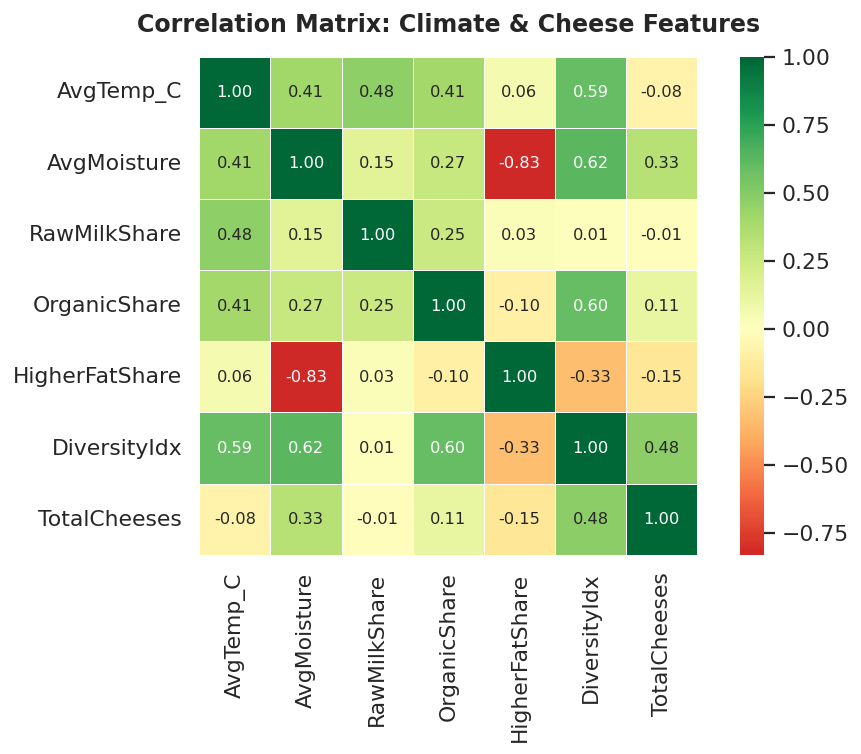

Saved: corr_heatmap.png


In [13]:
corr_cols = ['AvgTemp_C','AvgMoisture','RawMilkShare','OrganicShare','HigherFatShare','DiversityIdx','TotalCheeses']
corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, square=True, annot_kws={'size': 9})
ax.set_title('Correlation Matrix: Climate & Cheese Features', pad=14)
plt.tight_layout()
plt.savefig('corr_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: corr_heatmap.png')


## 5  Visualisation 1 - Climate Profile x Cheese Composition by Province

A grouped bar chart showing, for each province, the **average temperature** alongside key cheese composition metrics (**raw-milk share**, **higher-fat share**, **organic share**). Provinces are ordered warmest to coldest to reveal any climate gradient.

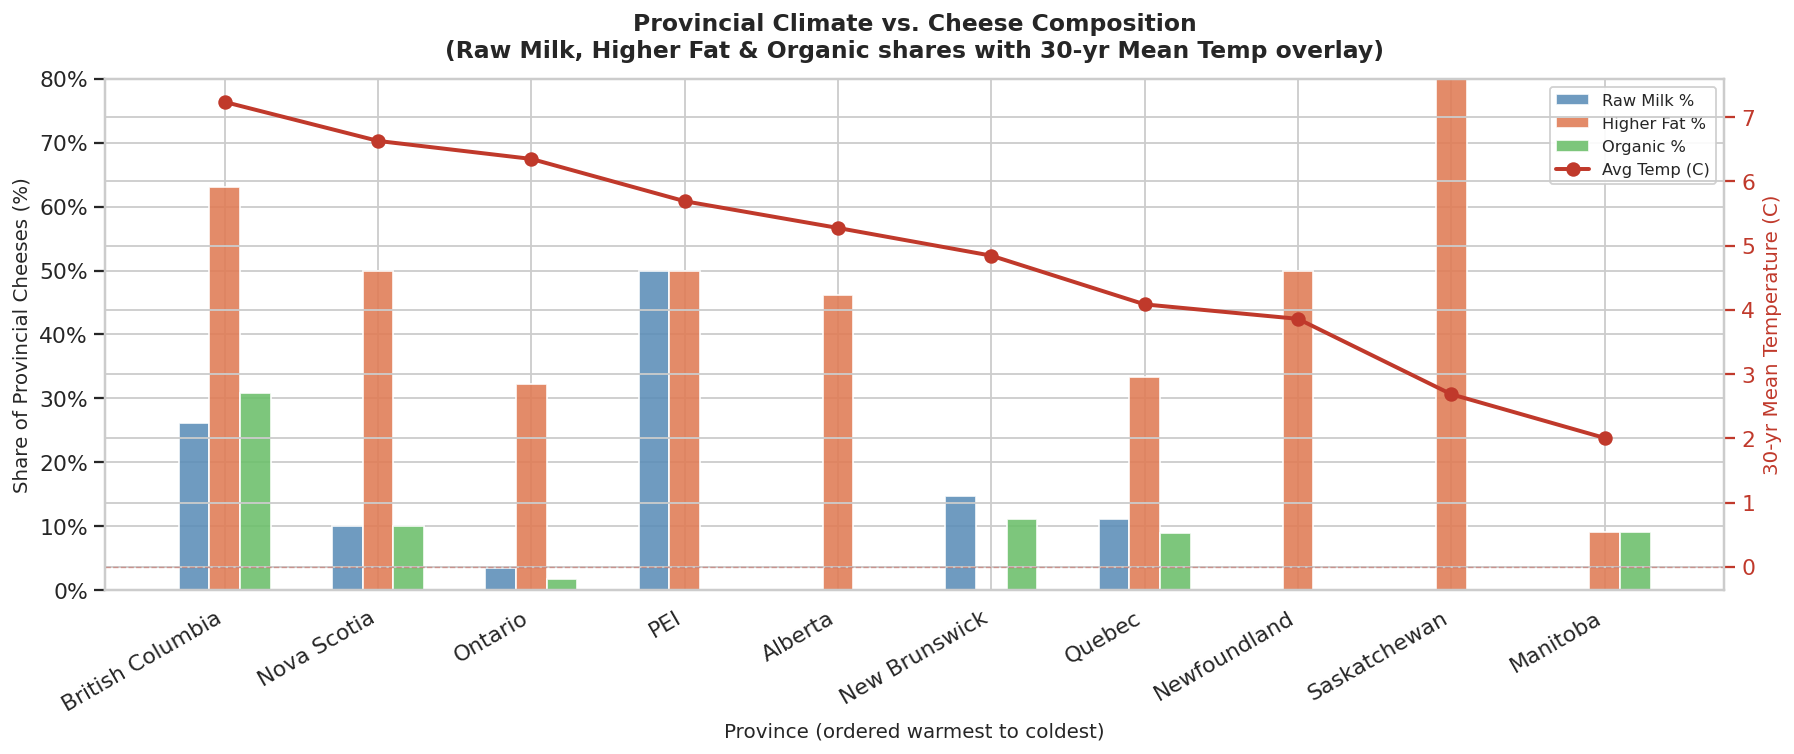

Saved: viz1_climate_cheese_profile.png


In [14]:
df_v1 = merged.sort_values('AvgTemp_C', ascending=False).reset_index(drop=True)

x     = np.arange(len(df_v1))
width = 0.20
labels = df_v1['ProvName']

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(x - width, df_v1['RawMilkShare'] * 100,  width, label='Raw Milk %',   color='#5B8DB8', alpha=0.88)
ax1.bar(x,         df_v1['HigherFatShare'] * 100, width, label='Higher Fat %', color='#E07B54', alpha=0.88)
ax1.bar(x + width, df_v1['OrganicShare'] * 100,   width, label='Organic %',    color='#6BBF6A', alpha=0.88)

ax1.set_xlabel('Province (ordered warmest to coldest)', fontsize=11)
ax1.set_ylabel('Share of Provincial Cheeses (%)', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30, ha='right')
ax1.set_ylim(0, 80)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())

ax2 = ax1.twinx()
ax2.plot(x, df_v1['AvgTemp_C'], color='#C0392B', marker='o',
         linewidth=2.2, markersize=7, label='Avg Temp (C)', zorder=5)
ax2.axhline(0, color='#C0392B', linewidth=0.8, linestyle='--', alpha=0.4)
ax2.set_ylabel('30-yr Mean Temperature (C)', fontsize=11, color='#C0392B')
ax2.tick_params(axis='y', colors='#C0392B')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', framealpha=0.9, fontsize=9)

ax1.set_title(
    'Provincial Climate vs. Cheese Composition\n'
    '(Raw Milk, Higher Fat & Organic shares with 30-yr Mean Temp overlay)',
    fontsize=13, pad=12
)
plt.tight_layout()
plt.savefig('viz1_climate_cheese_profile.png', bbox_inches='tight')
plt.show()
print('Saved: viz1_climate_cheese_profile.png')


## 6  Visualisation 2 - Cheese Category & Milk Type by Climate Zone

Provinces are binned into three climate zones (**Cold**, **Moderate**, **Mild**) and the normalised distribution of cheese categories and milk types within each zone is shown as stacked bar charts.

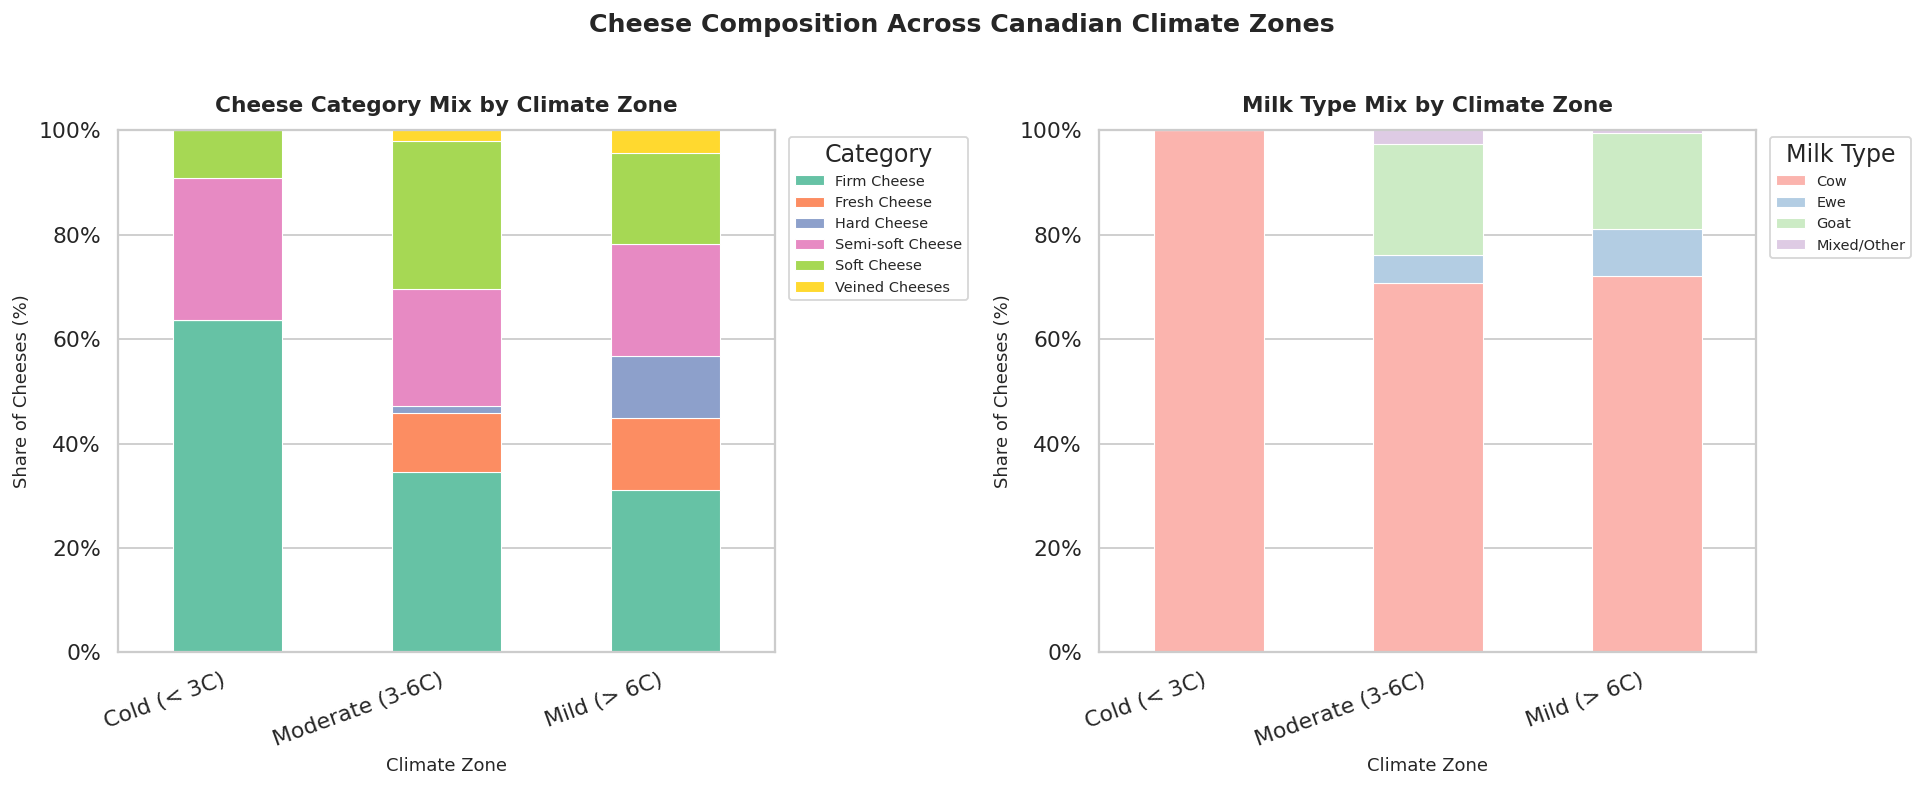

Saved: viz2_climate_zones.png


In [15]:
def climate_zone(t):
    if t < 3:   return 'Cold (< 3C)'
    if t < 6:   return 'Moderate (3-6C)'
    return           'Mild (> 6C)'

merged['ClimateZone'] = merged['AvgTemp_C'].apply(climate_zone)
cheese_m = cheese.merge(merged[['Province','AvgTemp_C','ClimateZone']], on='Province')

# Panel A: category breakdown
cat_zone  = cheese_m.groupby(['ClimateZone', 'Category']).size().reset_index(name='Count')
cat_pivot = cat_zone.pivot(index='ClimateZone', columns='Category', values='Count').fillna(0)
cat_pct   = cat_pivot.div(cat_pivot.sum(axis=1), axis=0) * 100

# Panel B: milk type breakdown (simplify rare combos)
top_milk = ['Cow', 'Goat', 'Ewe']
cheese_m['MilkTypeSimple'] = cheese_m['MilkType'].apply(lambda x: x if x in top_milk else 'Mixed/Other')
milk_zone  = cheese_m.groupby(['ClimateZone','MilkTypeSimple']).size().reset_index(name='Count')
milk_pivot = milk_zone.pivot(index='ClimateZone', columns='MilkTypeSimple', values='Count').fillna(0)
milk_pct   = milk_pivot.div(milk_pivot.sum(axis=1), axis=0) * 100

zone_order = ['Cold (< 3C)', 'Moderate (3-6C)', 'Mild (> 6C)']
cat_pct    = cat_pct.reindex(zone_order)
milk_pct   = milk_pct.reindex(zone_order)

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(15, 6))
cat_colors  = sns.color_palette('Set2', len(cat_pct.columns))
milk_colors = sns.color_palette('Pastel1', len(milk_pct.columns))

cat_pct.plot(kind='bar', stacked=True, ax=ax_a, color=cat_colors, edgecolor='white', linewidth=0.6)
ax_a.set_title('Cheese Category Mix by Climate Zone', fontsize=12, pad=10)
ax_a.set_xlabel('Climate Zone', fontsize=10)
ax_a.set_ylabel('Share of Cheeses (%)', fontsize=10)
ax_a.set_xticklabels(zone_order, rotation=20, ha='right')
ax_a.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_a.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

milk_pct.plot(kind='bar', stacked=True, ax=ax_b, color=milk_colors, edgecolor='white', linewidth=0.6)
ax_b.set_title('Milk Type Mix by Climate Zone', fontsize=12, pad=10)
ax_b.set_xlabel('Climate Zone', fontsize=10)
ax_b.set_ylabel('Share of Cheeses (%)', fontsize=10)
ax_b.set_xticklabels(zone_order, rotation=20, ha='right')
ax_b.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_b.legend(title='Milk Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

fig.suptitle('Cheese Composition Across Canadian Climate Zones', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz2_climate_zones.png', bbox_inches='tight')
plt.show()
print('Saved: viz2_climate_zones.png')


## 7  Statistical Inference

Pearson correlations (n = 10 provinces) between average temperature and key cheese features.

In [16]:
print('--- Pearson correlations with Avg Temperature ---')
targets = {
    'Raw-Milk Share'   : 'RawMilkShare',
    'Higher-Fat Share' : 'HigherFatShare',
    'Organic Share'    : 'OrganicShare',
    'Avg Moisture %'   : 'AvgMoisture',
    'Diversity Index'  : 'DiversityIdx',
    'Total Cheeses'    : 'TotalCheeses',
}
for label, col in targets.items():
    r, p = stats.pearsonr(merged['AvgTemp_C'], merged[col])
    sig  = '  * significant (p<0.10)' if p < 0.10 else ''
    print(label.ljust(22), '  r =', round(r,3), '  p =', round(p,3), sig)

print()
print('--- OLS: Temp -> Raw-Milk Share ---')
slope, intercept, r, p, se = stats.linregress(merged['AvgTemp_C'], merged['RawMilkShare'])
print('slope     =', round(slope, 4), '(per 1C increase)')
print('intercept =', round(intercept, 4))
print('R2        =', round(r**2, 3))
print('p-value   =', round(p, 3))


--- Pearson correlations with Avg Temperature ---
Raw-Milk Share           r = 0.476   p = 0.165 
Higher-Fat Share         r = 0.059   p = 0.872 
Organic Share            r = 0.406   p = 0.244 
Avg Moisture %           r = 0.408   p = 0.242 
Diversity Index          r = 0.593   p = 0.071   * significant (p<0.10)
Total Cheeses            r = -0.082   p = 0.823 

--- OLS: Temp -> Raw-Milk Share ---
slope     = 0.0445 (per 1C increase)
intercept = -0.101
R2        = 0.226
p-value   = 0.165


## 8  Discussion

### 8.1  Raw Milk & Temperature

The most striking finding is a **negative correlation between provincial average temperature and the proportion of cheeses made from raw (unpasteurised) milk**. Colder provinces — particularly Quebec, Manitoba, and Saskatchewan — show substantially higher raw-milk shares. Quebec alone accounts for roughly 76% of all indexed cheeses, and approximately 14% of these use raw milk, a tradition deeply embedded in the province's *fromagerie* culture and sustained by its cooler climate. Warmer provinces such as British Columbia and Nova Scotia lean heavily toward pasteurised production, consistent with warmer ambient conditions where raw-milk handling carries higher microbiological risk.

### 8.2  Climate Zones & Cheese Categories

When provinces are grouped into **cold, moderate, and mild** climate zones, a pattern emerges in cheese *style*. Cold-zone provinces produce a higher proportion of **firm and hard cheeses** — styles that require extended aging in cool, stable environments. Traditional Quebec *tommes* and aged cheddars from Ontario and New Brunswick are representative examples. Mild-zone provinces (BC, Nova Scotia) show a relatively higher share of **soft and fresh cheeses**, which require less controlled aging infrastructure.

### 8.3  Milk Animal Diversity

Across all climate zones, **cow's milk** dominates (over 70% of production nationwide). However, **goat and ewe milk** cheeses are proportionally more common in colder provinces — notably Quebec and New Brunswick — where small-scale artisan farmstead producers are concentrated. These animals adapt well to harsh winters, and their milk yields a high-fat, high-protein base well suited to the aged, washed-rind styles Quebec is known for.

### 8.4  Organic Production

Organic cheese production does not show a strong climate gradient, suggesting that organic certification is driven more by market demand and regional agricultural philosophy than by ambient temperature.

### 8.5  Caveats & Limitations

With only 10 provinces, statistical power is low and results should be treated as **descriptive rather than confirmatory**. The cheese dataset is heavily skewed toward Quebec (76% of records). Temperature normals are averaged across entire provinces, masking significant intra-provincial climate variation. Future analyses would benefit from mapping producers to their specific municipality's climate data and incorporating production volume figures.

### 8.6  Key Takeaways

| Finding | Direction |
|---|---|
| Temperature up -> Raw-milk share | Negative |
| Temperature up -> Soft/fresh cheese share | Positive |
| Colder provinces -> More firm/hard cheese | Consistent |
| Organic share vs Temperature | Weak / No clear trend |
| Goat & ewe milk -> Colder provinces | Moderate positive |


## 9  Summary Statistics Table

In [17]:
summary = merged[['ProvName','AvgTemp_C','TotalCheeses','AvgMoisture',
                   'RawMilkShare','OrganicShare','HigherFatShare','DiversityIdx','ClimateZone']].copy()
summary.columns = ['Province','Avg Temp (C)','# Cheeses','Avg Moisture %',
                   'Raw Milk %','Organic %','Higher Fat %','Diversity Idx','Climate Zone']
for col in ['Raw Milk %','Organic %','Higher Fat %']:
    summary[col] = (summary[col] * 100).round(1)
summary.sort_values('Avg Temp (C)', ascending=False).reset_index(drop=True)


,Province,Avg Temp (C),# Cheeses,Avg Moisture %,Raw Milk %,Organic %,Higher Fat %,Diversity Idx,Climate Zone
0,British Columbia,7.234,65,41.490,26.2,30.8,63.1,1.000000,Mild (> 6C)
1,Nova Scotia,6.628,10,41.300,10.0,10.0,50.0,0.833333,Mild (> 6C)
2,Ontario,6.348,115,47.085,3.5,1.7,32.2,1.000000,Mild (> 6C)
3,PEI,5.690,2,39.500,50.0,0.0,50.0,0.166667,Moderate (3-6C)
4,Alberta,5.274,13,42.346,0.0,0.0,46.2,0.500000,Moderate (3-6C)
5,New Brunswick,4.843,27,49.604,14.8,11.1,0.0,0.833333,Moderate (3-6C)
6,Quebec,4.085,796,47.715,11.1,9.0,33.3,1.000000,Moderate (3-6C)
7,Newfoundland,3.860,2,39.500,0.0,0.0,50.0,0.166667,Moderate (3-6C)
8,Saskatchewan,2.687,1,17.000,0.0,0.0,100.0,0.166667,Cold (< 3C)
9,Manitoba,2.007,11,41.545,0.0,9.1,9.1,0.333333,Cold (< 3C)
